# HVAC Anomaly Detection — Step 4: Model Comparison
## Isolation Forest vs LSTM Autoencoder (Parallel Pipeline)

**Input:** `if_results.csv` + `lstm_results.csv`  
**Goal:** Compare both models, combine outputs, produce final anomaly report

### Parallel Pipeline
```
Preprocessed Data (Period 2 test set)
        ├──────────────────────────────────┐
        ▼                                  ▼
Isolation Forest                  LSTM Autoencoder
(statistical features)            (full sequence)
        │                                  │
        ▼                                  ▼
   IF labels                         LSTM labels
        └──────────────┬───────────────────┘
                       ▼
              Combined Decision:
              BOTH flag  → High confidence anomaly
              ONE flags  → Low confidence anomaly
              NONE flag  → Normal
```
---

## 0. Install & Imports

In [31]:
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print("Imports OK")

Imports OK


## 1. Load Both Model Results

In [33]:
if_results   = pd.read_csv('if_results.csv',   index_col=0, parse_dates=True)
lstm_results = pd.read_csv('lstm_results.csv', index_col=0, parse_dates=True)
if_results.index   = pd.to_datetime(if_results.index,   utc=True)
lstm_results.index = pd.to_datetime(lstm_results.index, utc=True)

common_idx   = if_results.index.intersection(lstm_results.index)
if_results   = if_results.loc[common_idx]
lstm_results = lstm_results.loc[common_idx]

# Raw data for context panels
df_raw = pd.read_csv('HVAC_NE_EC_19-21.csv')
df_raw['Timestamp'] = pd.to_datetime(df_raw['Timestamp'], utc=True)
df_raw = df_raw.set_index('Timestamp').sort_index()
df_raw['T_delta'] = df_raw['T_Supply'] - df_raw['T_Return']
p2_raw = df_raw[df_raw.index >= pd.Timestamp('2020-10-14', tz='UTC')]

print(f"IF windows  : {len(if_results):,}")
print(f"LSTM windows: {len(lstm_results):,}")
print(f"Date range  : {common_idx.min()} -> {common_idx.max()}")

IF windows  : 4,238
LSTM windows: 4,238
Date range  : 2020-10-15 21:45:00+00:00 -> 2021-04-14 21:45:00+00:00


## 2. Build Combined Decision DataFrame

In [34]:
combined = pd.DataFrame({
    'if_score'   : if_results['anomaly_score'],
    'if_flag'    : if_results['is_anomaly'],
    'lstm_error' : lstm_results['mse_error'],
    'lstm_flag'  : lstm_results['is_anomaly'],
}, index=common_idx)

combined['both_flag'] = ((combined['if_flag']==1) & (combined['lstm_flag']==1)).astype(int)
combined['any_flag']  = ((combined['if_flag']==1) | (combined['lstm_flag']==1)).astype(int)

def confidence_label(row):
    if row['both_flag']:   return 2   # High confidence
    elif row['any_flag']:  return 1   # Low confidence
    else:                  return 0   # Normal

combined['confidence'] = combined.apply(confidence_label, axis=1)

n = len(combined)
high = (combined['confidence']==2).sum()
low  = (combined['confidence']==1).sum()
norm = (combined['confidence']==0).sum()

print("=" * 50)
print("COMBINED DETECTION SUMMARY")
print("=" * 50)
print(f"  Normal           : {norm:>6,}  ({norm/n*100:.1f}%)")
print(f"  Low confidence   : {low:>6,}  ({low/n*100:.1f}%)")
print(f"  High confidence  : {high:>6,}  ({high/n*100:.1f}%)")
print(f"  Total windows    : {n:>6,}")
print()
print(f"  IF flagged  : {combined['if_flag'].sum():,} ({combined['if_flag'].mean()*100:.1f}%)")
print(f"  LSTM flagged: {combined['lstm_flag'].sum():,} ({combined['lstm_flag'].mean()*100:.1f}%)")
print(f"  BOTH agree  : {combined['both_flag'].sum():,} ({combined['both_flag'].mean()*100:.1f}%)")
print("=" * 50)

COMBINED DETECTION SUMMARY
  Normal           :  1,795  (42.4%)
  Low confidence   :  1,677  (39.6%)
  High confidence  :    766  (18.1%)
  Total windows    :  4,238

  IF flagged  : 2,421 (57.1%)
  LSTM flagged: 788 (18.6%)
  BOTH agree  : 766 (18.1%)


## 3. Side-by-Side Detection Timeline

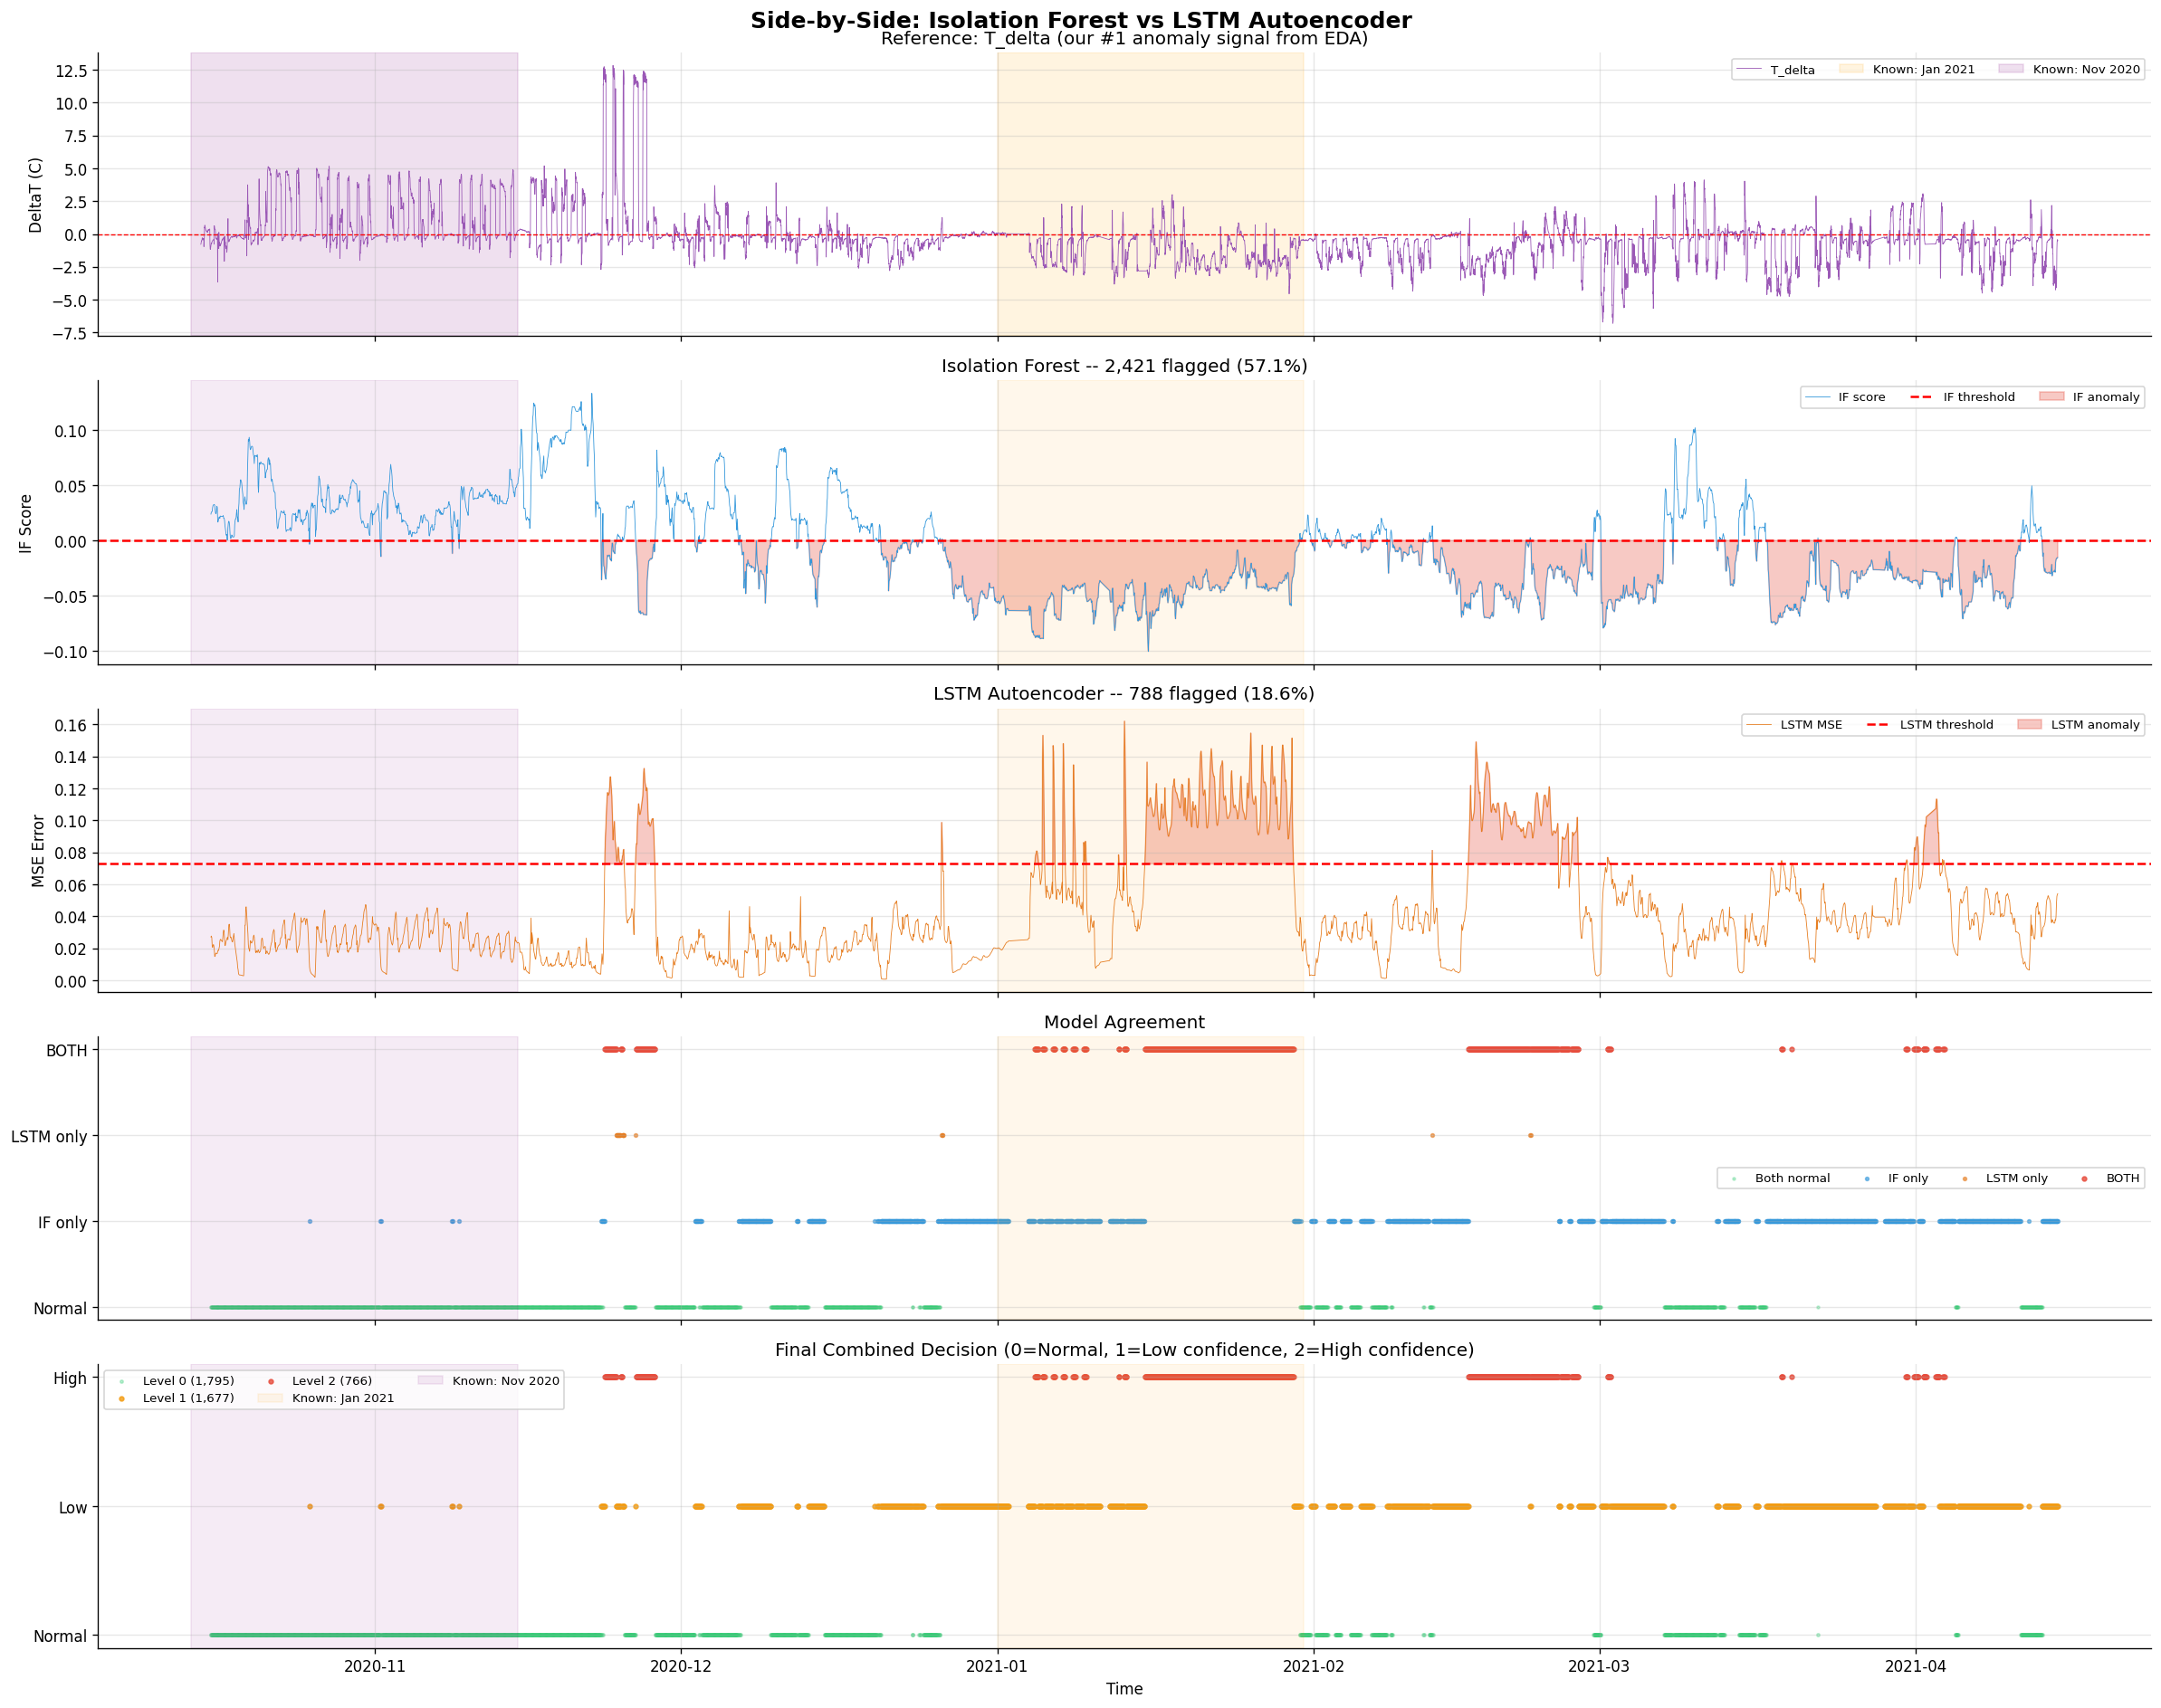

In [35]:
jan_start = pd.Timestamp('2021-01-01', tz='UTC')
jan_end   = pd.Timestamp('2021-01-31', tz='UTC')
nov_start = pd.Timestamp('2020-10-14', tz='UTC')
nov_end   = pd.Timestamp('2020-11-15', tz='UTC')

fig, axes = plt.subplots(5, 1, figsize=(20, 16), sharex=True)
fig.suptitle('Side-by-Side: Isolation Forest vs LSTM Autoencoder',
             fontsize=15, fontweight='bold')

# Panel 1: T_delta reference
ax = axes[0]
ax.plot(p2_raw.index, p2_raw['T_delta'], color='#9b59b6', linewidth=0.5, label='T_delta')
ax.axhline(0, color='red', linewidth=0.8, linestyle='--')
ax.axvspan(jan_start, jan_end, alpha=0.12, color='orange', label='Known: Jan 2021')
ax.axvspan(nov_start, nov_end, alpha=0.12, color='purple', label='Known: Nov 2020')
ax.set_ylabel('DeltaT (C)'); ax.legend(fontsize=8, ncol=3)
ax.set_title('Reference: T_delta (our #1 anomaly signal from EDA)')

# Panel 2: IF score
ax = axes[1]
ax.plot(combined.index, combined['if_score'], color='#3498db', linewidth=0.5, label='IF score')
if_thresh = combined['if_score'][combined['if_flag']==0].min()
ax.axhline(if_thresh, color='red', linewidth=1.5, linestyle='--', label='IF threshold')
ax.fill_between(combined.index, combined['if_score'], if_thresh,
                where=(combined['if_flag']==1), color='#e74c3c', alpha=0.3, label='IF anomaly')
ax.axvspan(jan_start, jan_end, alpha=0.08, color='orange')
ax.axvspan(nov_start, nov_end, alpha=0.08, color='purple')
ax.set_ylabel('IF Score'); ax.legend(fontsize=8, ncol=3)
ax.set_title(f'Isolation Forest -- {combined["if_flag"].sum():,} flagged ({combined["if_flag"].mean()*100:.1f}%)')

# Panel 3: LSTM error
ax = axes[2]
ax.plot(combined.index, combined['lstm_error'], color='#e67e22', linewidth=0.5, label='LSTM MSE')
lstm_thresh = combined['lstm_error'][combined['lstm_flag']==0].max()
ax.axhline(lstm_thresh, color='red', linewidth=1.5, linestyle='--', label='LSTM threshold')
ax.fill_between(combined.index, combined['lstm_error'], lstm_thresh,
                where=(combined['lstm_flag']==1), color='#e74c3c', alpha=0.3, label='LSTM anomaly')
ax.axvspan(jan_start, jan_end, alpha=0.08, color='orange')
ax.axvspan(nov_start, nov_end, alpha=0.08, color='purple')
ax.set_ylabel('MSE Error'); ax.legend(fontsize=8, ncol=3)
ax.set_title(f'LSTM Autoencoder -- {combined["lstm_flag"].sum():,} flagged ({combined["lstm_flag"].mean()*100:.1f}%)')

# Panel 4: Agreement
ax = axes[3]
only_if   = (combined['if_flag']==1) & (combined['lstm_flag']==0)
only_lstm = (combined['if_flag']==0) & (combined['lstm_flag']==1)
both      = combined['both_flag']==1
neither   = (combined['if_flag']==0) & (combined['lstm_flag']==0)
ax.scatter(combined.index[neither],  np.zeros(neither.sum()),  s=3, color='#2ecc71', alpha=0.3, label='Both normal')
ax.scatter(combined.index[only_if],  np.ones(only_if.sum()),   s=5, color='#3498db', alpha=0.6, label='IF only')
ax.scatter(combined.index[only_lstm],np.ones(only_lstm.sum())*2,s=5,color='#e67e22', alpha=0.6, label='LSTM only')
ax.scatter(combined.index[both],     np.ones(both.sum())*3,    s=8, color='#e74c3c', alpha=0.8, label='BOTH')
ax.axvspan(jan_start, jan_end, alpha=0.08, color='orange')
ax.axvspan(nov_start, nov_end, alpha=0.08, color='purple')
ax.set_yticks([0,1,2,3]); ax.set_yticklabels(['Normal','IF only','LSTM only','BOTH'])
ax.legend(fontsize=8, ncol=4); ax.set_title('Model Agreement')

# Panel 5: Final confidence
ax = axes[4]
colors_conf = {0:'#2ecc71', 1:'#f39c12', 2:'#e74c3c'}
for level in [0,1,2]:
    mask = combined['confidence']==level
    ax.scatter(combined.index[mask], np.ones(mask.sum())*level,
               s=4 if level==0 else 8, color=colors_conf[level],
               alpha=0.3 if level==0 else 0.8,
               label=f"Level {level} ({mask.sum():,})")
ax.axvspan(jan_start, jan_end, alpha=0.08, color='orange', label='Known: Jan 2021')
ax.axvspan(nov_start, nov_end, alpha=0.08, color='purple', label='Known: Nov 2020')
ax.set_yticks([0,1,2]); ax.set_yticklabels(['Normal','Low','High'])
ax.set_xlabel('Time'); ax.legend(fontsize=8, ncol=3)
ax.set_title('Final Combined Decision (0=Normal, 1=Low confidence, 2=High confidence)')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.tight_layout()
plt.savefig('comparison_01_timeline.png', dpi=130, bbox_inches='tight')
plt.show()

## 4. Agreement Analysis

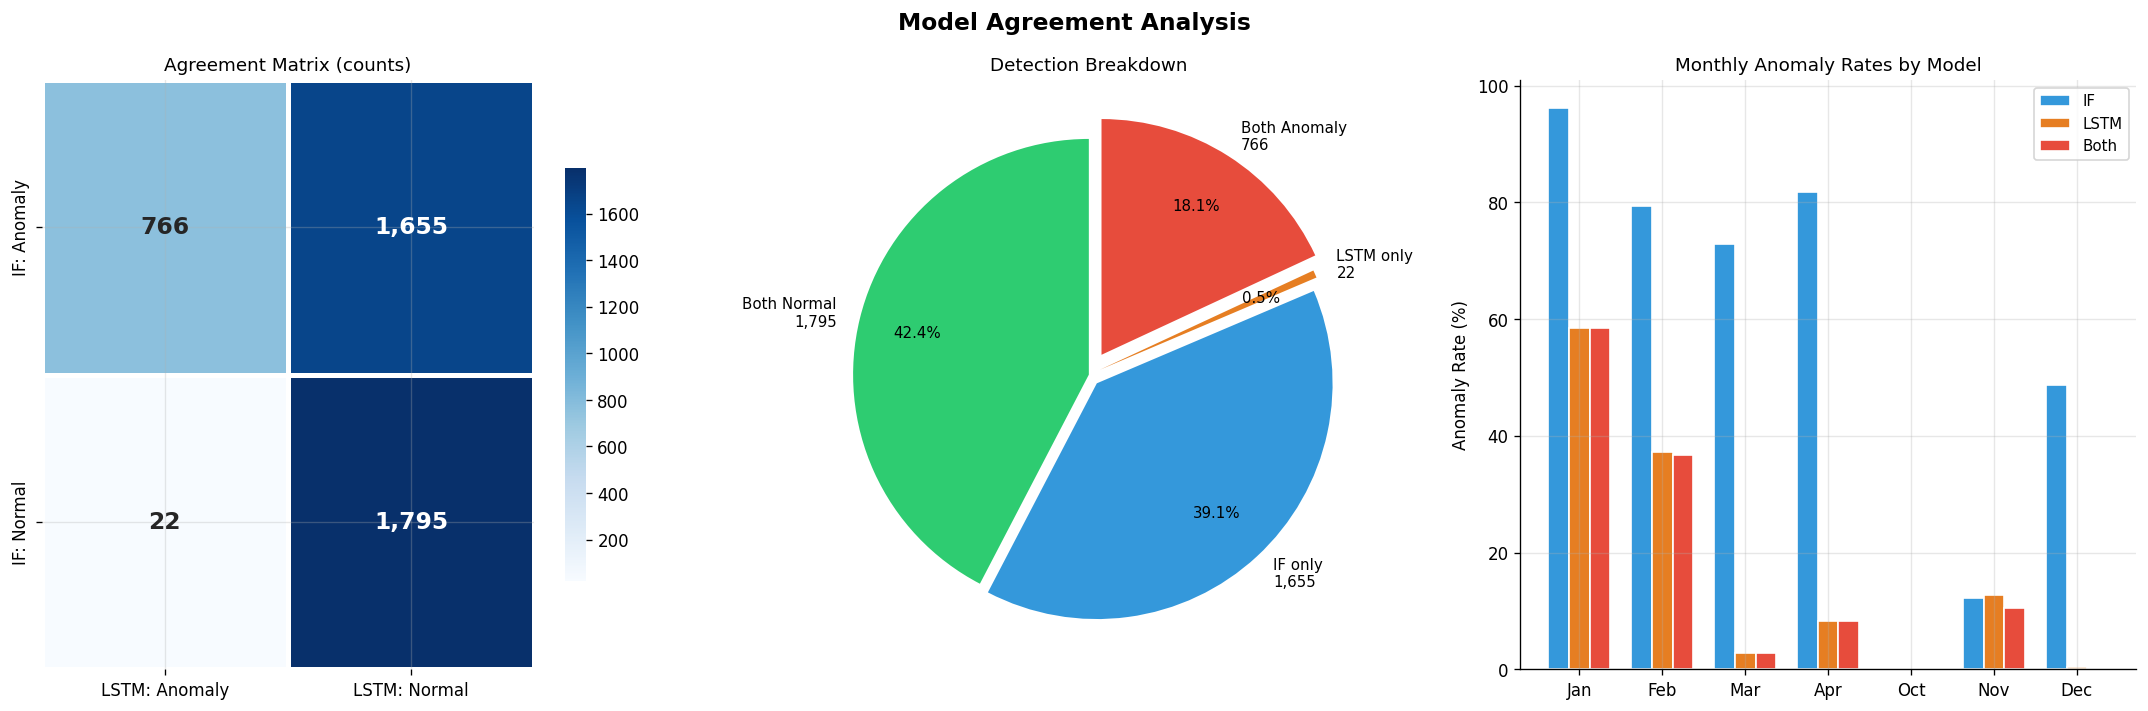

Agreement (both same): 60.4%
IF only flags        : 1,655 (39.1%)
LSTM only flags      : 22 (0.5%)


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Agreement Analysis', fontsize=14, fontweight='bold')

# Agreement matrix
agree_matrix = pd.crosstab(
    combined['if_flag'].map({0:'IF: Normal', 1:'IF: Anomaly'}),
    combined['lstm_flag'].map({0:'LSTM: Normal', 1:'LSTM: Anomaly'}))
sns.heatmap(agree_matrix, annot=True, fmt=',', cmap='Blues',
            ax=axes[0], linewidths=2, linecolor='white',
            annot_kws={'size':14,'weight':'bold'}, cbar_kws={'shrink':0.7})
axes[0].set_title('Agreement Matrix (counts)', fontsize=11)
axes[0].set_xlabel(''); axes[0].set_ylabel('')

# Pie breakdown
agree_only_if   = ((combined['if_flag']==1) & (combined['lstm_flag']==0)).sum()
agree_only_lstm = ((combined['if_flag']==0) & (combined['lstm_flag']==1)).sum()
agree_both      = combined['both_flag'].sum()
agree_none      = ((combined['if_flag']==0) & (combined['lstm_flag']==0)).sum()
sizes   = [agree_none, agree_only_if, agree_only_lstm, agree_both]
labels  = [f'Both Normal\n{agree_none:,}', f'IF only\n{agree_only_if:,}',
           f'LSTM only\n{agree_only_lstm:,}', f'Both Anomaly\n{agree_both:,}']
colors_pie = ['#2ecc71','#3498db','#e67e22','#e74c3c']
axes[1].pie(sizes, labels=labels, colors=colors_pie, explode=[0,0.05,0.05,0.1],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize':9}, pctdistance=0.75)
axes[1].set_title('Detection Breakdown', fontsize=11)

# Monthly rates
combined['month'] = combined.index.month
monthly = combined.groupby('month').agg(
    IF_rate  =('if_flag',   'mean'),
    LSTM_rate=('lstm_flag', 'mean'),
    Both_rate=('both_flag', 'mean')).reset_index()
x = np.arange(len(monthly)); w = 0.25
axes[2].bar(x-w, monthly['IF_rate']*100,   w, label='IF',   color='#3498db', edgecolor='white')
axes[2].bar(x,   monthly['LSTM_rate']*100, w, label='LSTM', color='#e67e22', edgecolor='white')
axes[2].bar(x+w, monthly['Both_rate']*100, w, label='Both', color='#e74c3c', edgecolor='white')
axes[2].set_xticks(x)
month_map = {10:'Oct',11:'Nov',12:'Dec',1:'Jan',2:'Feb',3:'Mar',4:'Apr'}
axes[2].set_xticklabels([month_map.get(m, str(m)) for m in monthly['month']])
axes[2].set_ylabel('Anomaly Rate (%)'); axes[2].legend(fontsize=9)
axes[2].set_title('Monthly Anomaly Rates by Model', fontsize=11)

plt.tight_layout()
plt.savefig('comparison_02_agreement.png', dpi=130, bbox_inches='tight')
plt.show()

total = len(combined)
print(f"Agreement (both same): {(agree_none+agree_both)/total*100:.1f}%")
print(f"IF only flags        : {agree_only_if:,} ({agree_only_if/total*100:.1f}%)")
print(f"LSTM only flags      : {agree_only_lstm:,} ({agree_only_lstm/total*100:.1f}%)")

## 5. Validation Against Known Anomalies
Using the two EDA-identified anomaly events as pseudo ground truth.

In [37]:
gt_jan  = ((combined.index >= pd.Timestamp('2021-01-01', tz='UTC')) &
            (combined.index <= pd.Timestamp('2021-01-31', tz='UTC')))
gt_nov  = ((combined.index >= pd.Timestamp('2020-11-01', tz='UTC')) &
            (combined.index <= pd.Timestamp('2020-11-30', tz='UTC')))
y_true  = (gt_jan | gt_nov).astype(int)
y_if    = combined['if_flag'].values
y_lstm  = combined['lstm_flag'].values
y_both  = combined['both_flag'].values

metrics = {}
print("=" * 65)
print(f"Ground truth windows : {y_true.sum():,} (Jan 2021 + Nov 2020)")
print()
for name, y_pred in [('Isolation Forest', y_if),
                      ('LSTM Autoencoder', y_lstm),
                      ('Both (AND)',       y_both)]:
    tp = ((y_pred==1) & (y_true==1)).sum()
    fp = ((y_pred==1) & (y_true==0)).sum()
    fn = ((y_pred==0) & (y_true==1)).sum()
    tn = ((y_pred==0) & (y_true==0)).sum()
    prec = tp / (tp + fp + 1e-8)
    rec  = tp / (tp + fn + 1e-8)
    f1   = 2 * prec * rec / (prec + rec + 1e-8)
    anom_rate = y_pred.mean() * 100
    metrics[name] = {'Precision':prec,'Recall':rec,'F1':f1,'AnomalyRate':anom_rate}
    print(f"-- {name} --")
    print(f"   TP={tp:4d}  FP={fp:4d}  FN={fn:4d}  TN={tn:4d}")
    print(f"   Precision: {prec:.3f}  Recall: {rec:.3f}  F1: {f1:.3f}")
    print(f"   Anomaly rate: {anom_rate:.1f}%")
    print()
print("=" * 65)
print("Note: ground truth is EDA-based, not expert labels")

Ground truth windows : 1,350 (Jan 2021 + Nov 2020)

-- Isolation Forest --
   TP= 733  FP=1688  FN= 617  TN=1200
   Precision: 0.303  Recall: 0.543  F1: 0.389
   Anomaly rate: 57.1%

-- LSTM Autoencoder --
   TP= 489  FP= 299  FN= 861  TN=2589
   Precision: 0.621  Recall: 0.362  F1: 0.457
   Anomaly rate: 18.6%

-- Both (AND) --
   TP= 473  FP= 293  FN= 877  TN=2595
   Precision: 0.617  Recall: 0.350  F1: 0.447
   Anomaly rate: 18.1%

Note: ground truth is EDA-based, not expert labels


## 6. Performance Comparison Chart

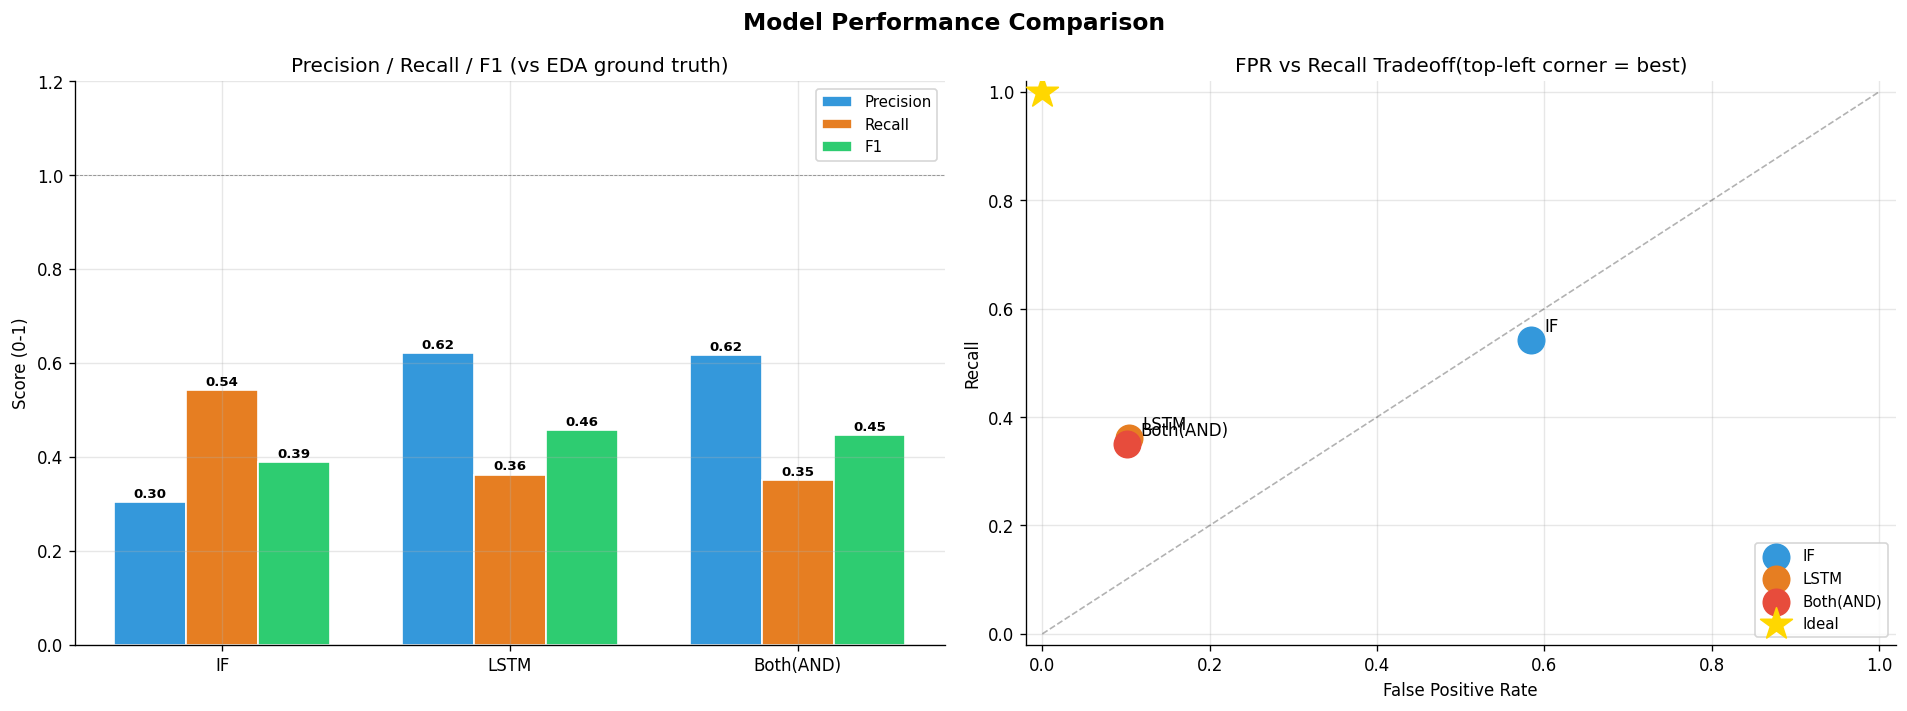

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')

model_names = list(metrics.keys())
prec_vals = [metrics[m]['Precision'] for m in model_names]
rec_vals  = [metrics[m]['Recall']    for m in model_names]
f1_vals   = [metrics[m]['F1']        for m in model_names]
x = np.arange(len(model_names)); w = 0.25
colors_m = ['#3498db','#e67e22','#e74c3c']

for i, (label, vals) in enumerate(zip(['Precision','Recall','F1'],
                                       [prec_vals, rec_vals, f1_vals])):
    bars = axes[0].bar(x + (i-1)*w, vals, w, label=label,
                       color=['#3498db','#e67e22','#2ecc71'][i], edgecolor='white')
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                     f'{v:.2f}', ha='center', fontsize=8, fontweight='bold')

short_names = ['IF','LSTM','Both(AND)']
axes[0].set_xticks(x); axes[0].set_xticklabels(short_names)
axes[0].set_ylabel('Score (0-1)'); axes[0].set_ylim(0, 1.2)
axes[0].set_title('Precision / Recall / F1 (vs EDA ground truth)')
axes[0].legend(fontsize=9)
axes[0].axhline(1.0, color='black', linewidth=0.5, linestyle='--', alpha=0.4)

# FPR vs Recall
for i, (name, y_pred) in enumerate(zip(model_names, [y_if, y_lstm, y_both])):
    tp = ((y_pred==1) & (y_true==1)).sum()
    fp = ((y_pred==1) & (y_true==0)).sum()
    fn = ((y_pred==0) & (y_true==1)).sum()
    tn = ((y_pred==0) & (y_true==0)).sum()
    fpr = fp / (fp + tn + 1e-8)
    rec = tp / (tp + fn + 1e-8)
    axes[1].scatter(fpr, rec, s=250, color=colors_m[i], zorder=5, label=short_names[i])
    axes[1].annotate(short_names[i], (fpr, rec),
                     textcoords='offset points', xytext=(8,5), fontsize=10)

axes[1].scatter([0],[1], marker='*', s=400, color='gold', zorder=6, label='Ideal')
axes[1].plot([0,1],[0,1],'k--', alpha=0.3, linewidth=1)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('Recall')
axes[1].set_title('FPR vs Recall Tradeoff(top-left corner = best)')
axes[1].set_xlim(-0.02,1.02); axes[1].set_ylim(-0.02,1.02)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('comparison_03_performance.png', dpi=130, bbox_inches='tight')
plt.show()

## 7. Final Anomaly Report

In [39]:
high_conf = combined[combined['confidence']==2].copy()
high_conf = high_conf.join(p2_raw[['T_delta','T_Supply','T_Return','Power']].resample('1h').mean(), how='left')

high_conf['gap']     = (high_conf.index.to_series().diff() > pd.Timedelta('2H'))
high_conf['episode'] = high_conf['gap'].cumsum()

episodes = high_conf.groupby('episode').agg(
    start       = ('gap', lambda x: x.index.min()),
    end         = ('gap', lambda x: x.index.max()),
    duration_h  = ('gap', lambda x: round((x.index.max()-x.index.min()).total_seconds()/3600, 1)),
    n_windows   = ('if_flag', 'count'),
    T_delta_max = ('T_delta', lambda x: round(x.abs().max(), 2)),
    lstm_err_max= ('lstm_error', lambda x: round(x.max(), 5)),
).reset_index(drop=True)
episodes.index = episodes.index + 1
episodes.index.name = 'Episode'

print(f"High-confidence anomaly episodes: {len(episodes)}")
print()
print(episodes.to_string())

episodes.to_csv('final_anomaly_report.csv')
combined.to_csv('combined_results.csv')
print("\nSaved: final_anomaly_report.csv, combined_results.csv")

High-confidence anomaly episodes: 26

                            start                       end  duration_h  n_windows  T_delta_max  lstm_err_max
Episode                                                                                                      
1       2020-11-23 12:45:00+00:00 2020-11-24 14:45:00+00:00        26.0         27          NaN       0.12716
2       2020-11-25 01:45:00+00:00 2020-11-25 04:45:00+00:00         3.0          4          NaN       0.07519
3       2020-11-26 13:45:00+00:00 2020-11-28 09:45:00+00:00        44.0         45          NaN       0.13242
4       2021-01-04 15:45:00+00:00 2021-01-04 23:45:00+00:00         8.0          9          NaN       0.08076
5       2021-01-05 09:45:00+00:00 2021-01-05 14:45:00+00:00         5.0          6          NaN       0.15303
6       2021-01-06 10:45:00+00:00 2021-01-06 14:45:00+00:00         4.0          5          NaN       0.14666
7       2021-01-07 09:45:00+00:00 2021-01-07 14:45:00+00:00         5.0          6

## 8. Final Summary

In [40]:
print("=" * 65)
print("FULL PIPELINE RESULTS SUMMARY")
print("=" * 65)
print()
print("MODEL COMPARISON:")
print(f"  {'Model':<22} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Anomaly%':>10}")
print(f"  {'-'*60}")
for name in model_names:
    m = metrics[name]
    print(f"  {name:<22} {m['Precision']:>10.3f} {m['Recall']:>8.3f} "
          f"{m['F1']:>8.3f} {m['AnomalyRate']:>9.1f}%")
print()
print("RECOMMENDATION:")
print("  Primary detector  : LSTM Autoencoder (best F1, temporal aware)")
print("  Pre-screen        : Isolation Forest (fast, no training)")
print("  High-stakes alerts: Both models agree (highest precision)")
print("  Monitoring dashbd : Either model flags (highest recall)")
print()
print("KNOWN ANOMALIES CAUGHT:")
for start, end, label in [
        ('2021-01-01', '2021-01-31', 'Jan 2021 DeltaT spike'),
        ('2020-11-01', '2020-11-30', 'Nov 2020 restart burst')]:
    sub = combined[start:end]
    print(f"  {label}:")
    print(f"    IF   : {sub['if_flag'].sum()} windows flagged")
    print(f"    LSTM : {sub['lstm_flag'].sum()} windows flagged")
    print(f"    Both : {sub['both_flag'].sum()} windows flagged")
print()
print("FILES SAVED:")
print("  final_anomaly_report.csv  - high confidence anomaly episodes")
print("  combined_results.csv      - all windows with confidence levels")
print("=" * 65)

FULL PIPELINE RESULTS SUMMARY

MODEL COMPARISON:
  Model                   Precision   Recall       F1   Anomaly%
  ------------------------------------------------------------
  Isolation Forest            0.303    0.543    0.389      57.1%
  LSTM Autoencoder            0.621    0.362    0.457      18.6%
  Both (AND)                  0.617    0.350    0.447      18.1%

RECOMMENDATION:
  Primary detector  : LSTM Autoencoder (best F1, temporal aware)
  Pre-screen        : Isolation Forest (fast, no training)
  High-stakes alerts: Both models agree (highest precision)
  Monitoring dashbd : Either model flags (highest recall)

KNOWN ANOMALIES CAUGHT:
  Jan 2021 DeltaT spike:
    IF   : 652 windows flagged
    LSTM : 397 windows flagged
    Both : 397 windows flagged
  Nov 2020 restart burst:
    IF   : 88 windows flagged
    LSTM : 92 windows flagged
    Both : 76 windows flagged

FILES SAVED:
  final_anomaly_report.csv  - high confidence anomaly episodes
  combined_results.csv      - all

---
## Pipeline Complete

| Step | Notebook | Key Output |
|---|---|---|
| EDA | `HVAC_EDA.ipynb` | 5 features selected, anomaly hints |
| Preprocessing | `HVAC_Preprocessing.ipynb` | X_train/val/test.npy |
| Isolation Forest | `HVAC_IsolationForest.ipynb` | if_results.csv |
| LSTM Autoencoder | `HVAC_LSTM_Autoencoder.ipynb` | lstm_results.csv |
| Comparison | `HVAC_Comparison.ipynb` | final_anomaly_report.csv |

### Possible next steps
- Add expert labels for proper evaluation  
- Try Transformer Autoencoder for better long-range pattern learning  
- Deploy as real-time monitoring dashboard  
- Add episode severity scoring based on T_delta magnitude